# Freight Rate Prediction — Preprocessing, Feature Engineering, Training & Validation

Follow-up from `01_eda.ipynb`. This notebook:
1. Cleans the data according to EDA findings (fixing the `weight` sign error, handling missing values)
2. Engineers features (coordinates, cyclical seasonal features, etc.) via `src/features.py`
3. Trains the model using a **time-based split** (instead of random split) so that validation reflects real-world performance (extrapolating to unseen months)
4. Evaluates the model and inspects feature importance
5. Retrains the final model on the entire `train_test.csv` dataset, then predicts `validation.csv` and `december_chart_inputs.csv`
6. Runs `score.py` for format validation and generates the December chart

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

from features import FeatureRecipe, FEATURE_COLUMNS, CATEGORICAL_FEATURES

pd.set_option('display.width', 140)
plt.rcParams['figure.dpi'] = 110
RNG_SEED = 42

train_full = pd.read_csv('../data/train-test.csv')
validation = pd.read_csv('../data/validation.csv')
template = pd.read_csv('../data/validation-predictions-template.csv')
dec_inputs = pd.read_csv('../data/december-chart-inputs.csv')

train_full['date'] = pd.to_datetime(train_full['date'])
validation['date'] = pd.to_datetime(validation['date'])
dec_inputs['date'] = pd.to_datetime(dec_inputs['date'])

print(train_full.shape, validation.shape, dec_inputs.shape)

(48000, 14) (12000, 13) (31, 7)


## 1. Time-based Train / Internal-Validation Split

`train_test.csv` covers Jan-Oct 2025. Because `validation.csv` & December data are located **after** this range (Nov-Dec 2025), the most representative internal validation is to split by **time**, rather than randomly:

- **Train**: January – August 2025 (~8 months)
- **Internal validation (holdout)**: September – October 2025 (~the last 2 months, unseen by the model)

This simulates a real-world scenario: the model is trained on past data and evaluated on its ability to extrapolate to unseen future periods — exactly like predicting `validation.csv` (Nov-Dec) later on.

In [2]:
cutoff = pd.Timestamp('2025-09-01')
tr_part = train_full[train_full['date'] < cutoff].reset_index(drop=True)
ho_part = train_full[train_full['date'] >= cutoff].reset_index(drop=True)

print(f"Train part : {len(tr_part):,} baris ({tr_part['date'].min().date()} - {tr_part['date'].max().date()})")
print(f"Holdout part: {len(ho_part):,} baris ({ho_part['date'].min().date()} - {ho_part['date'].max().date()})")

Train part : 38,477 baris (2025-01-01 - 2025-08-31)
Holdout part: 9,523 baris (2025-09-01 - 2025-10-31)


## 2. Fit Feature Recipe (ONLY on the training set to prevent data leakage from the holdout set)

In [3]:
recipe = FeatureRecipe().fit(tr_part, validation)  # coords juga diambil dari validation (utk kota2 baru)

X_tr = recipe.build_matrix(tr_part)
y_tr = np.log1p(tr_part['posted_rate'])

X_ho = recipe.build_matrix(ho_part)
y_ho = np.log1p(ho_part['posted_rate'])

for col in CATEGORICAL_FEATURES:
    X_tr[col] = X_tr[col].astype('category')
    X_ho[col] = X_ho[col].astype('category')

print(X_tr.shape, X_ho.shape)
X_tr.head()

(38477, 13) (9523, 13)


,distance,weight_final,equipment,pickup_lat,pickup_lon,delivery_lat,delivery_lon,market_index_final,quote_signal_final,doy_sin,doy_cos,dow,is_weekend
0,274.3,30658.0,Dry Van,38.09122,-76.78906,38.16908,-72.74564,0.95684,2.39595,0.017202,0.999852,2,0
1,280.5,17555.0,Reefer,38.09122,-76.78906,39.22317,-72.96710,0.97623,2.43355,0.017202,0.999852,2,0
2,967.8,31721.0,Dry Van,39.22317,-72.96710,44.30296,-87.52871,1.00971,1.84491,0.017202,0.999852,2,0
3,965.4,32333.0,Dry Van,39.55328,-72.18051,34.84933,-86.28940,0.94518,1.87712,0.017202,0.999852,2,0
4,541.9,35183.0,Reefer,31.83025,-94.38343,35.29479,-88.08915,0.98480,2.56300,0.017202,0.999852,2,0


## 3. Model Training (LightGBM)

**Why Gradient Boosting (LightGBM)?**
- More robust against outliers & noise identified during EDA (weight sign-error residuals, distance mismatches, extreme rate-per-mile values) compared to linear models.
- Automatically captures non-linear interactions between features (e.g., `equipment` × `distance` × seasonality) without requiring manual feature crossing.
- Natively supports categorical features (`equipment`, `dow`) without needing manual one-hot encoding.
- Fast training and prediction speeds even with tens of thousands of rows — ideal for rapid iteration.
- The target is log-transformed (`log1p`) because the `posted_rate` distribution is right-skewed (EDA finding #2) — ensuring a more balanced training loss and guaranteeing positive predictions after `expm1`.

Early stopping is applied at this stage (using the Sep–Oct holdout set) to determine the optimal number of trees before overfitting occurs.

In [4]:
train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=CATEGORICAL_FEATURES)
holdout_set = lgb.Dataset(X_ho, label=y_ho, categorical_feature=CATEGORICAL_FEATURES, reference=train_set)

params = dict(
    objective='regression',
    metric='mae',
    learning_rate=0.03,
    num_leaves=31,
    min_data_in_leaf=30,
    feature_fraction=0.85,
    bagging_fraction=0.85,
    bagging_freq=1,
    lambda_l2=1.0,
    seed=RNG_SEED,
    verbosity=-1,
)

model_cv = lgb.train(
    params,
    train_set,
    num_boost_round=3000,
    valid_sets=[train_set, holdout_set],
    valid_names=['train', 'holdout'],
    callbacks=[lgb.early_stopping(stopping_rounds=100), lgb.log_evaluation(period=200)],
)

best_iter = model_cv.best_iteration
print("\nBest iteration:", best_iter)

Training until validation scores don't improve for 100 rounds
[200]	train's l1: 0.0414893	holdout's l1: 0.0530023
Early stopping, best iteration is:
[232]	train's l1: 0.0407536	holdout's l1: 0.0527474

Best iteration: 232


## 4. Holdout Evaluation (Sep–Oct, Unseen by Model)

In [5]:
pred_log = model_cv.predict(X_ho, num_iteration=best_iter)
pred_dollar = np.expm1(pred_log)
actual_dollar = ho_part['posted_rate'].to_numpy()

mae = mean_absolute_error(actual_dollar, pred_dollar)
rmse = np.sqrt(mean_squared_error(actual_dollar, pred_dollar))
mape = np.mean(np.abs((actual_dollar - pred_dollar) / actual_dollar)) * 100

print(f"MAE  : ${mae:,.2f}")
print(f"RMSE : ${rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")
print(f"\nRata-rata posted_rate di holdout: ${actual_dollar.mean():,.2f}  ->  MAE relatif ~{mae/actual_dollar.mean()*100:.1f}% dari rata-rata harga")

MAE  : $131.98
RMSE : $639.97
MAPE : 5.84%

Rata-rata posted_rate di holdout: $2,392.45  ->  MAE relatif ~5.5% dari rata-rata harga


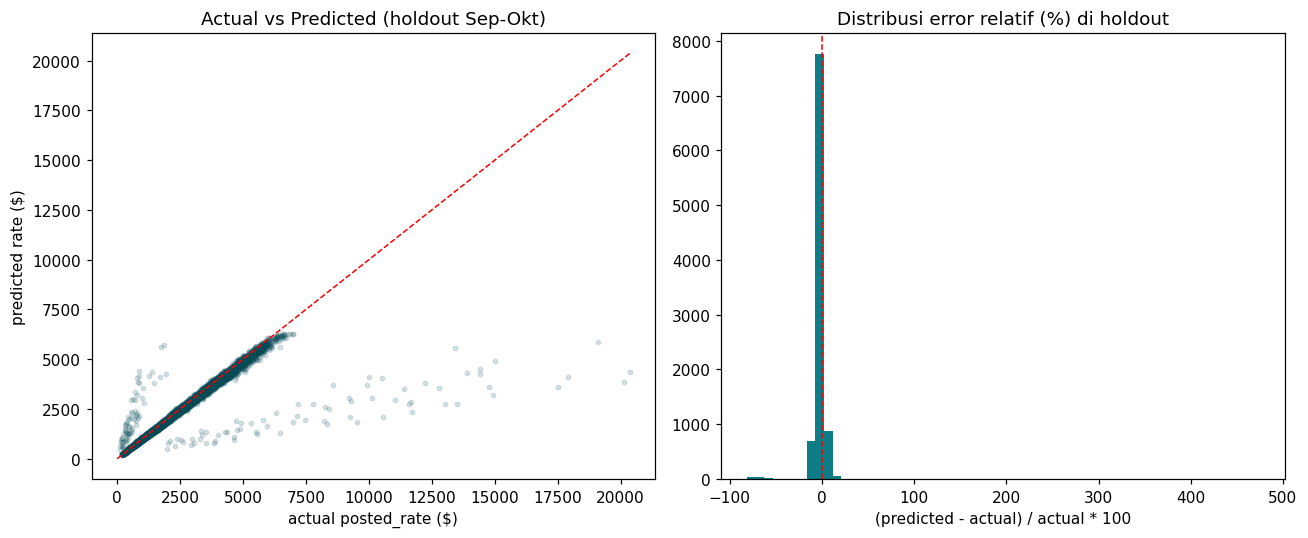

Persentil error absolut:
count    9523.000000
mean        5.841385
std        24.850104
min         0.000449
50%         2.952936
75%         4.926069
90%         7.094934
95%         8.639821
99%        75.727982
max       474.680649
dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].scatter(actual_dollar, pred_dollar, alpha=0.15, s=8, color='#064A56')
lims = [0, max(actual_dollar.max(), pred_dollar.max())]
axes[0].plot(lims, lims, color='red', linewidth=1, linestyle='--')
axes[0].set_xlabel('actual posted_rate ($)')
axes[0].set_ylabel('predicted rate ($)')
axes[0].set_title('Actual vs Predicted (holdout Sep-Okt)')

residual_pct = (pred_dollar - actual_dollar) / actual_dollar * 100
axes[1].hist(residual_pct, bins=60, color='#0E7C86')
axes[1].axvline(0, color='red', linewidth=1, linestyle='--')
axes[1].set_title('Distribusi error relatif (%) di holdout')
axes[1].set_xlabel('(predicted - actual) / actual * 100')

plt.tight_layout()
plt.show()

print("Persentil error absolut:")
print(pd.Series(np.abs(residual_pct)).describe(percentiles=[.5,.75,.9,.95,.99]))

**Holdout result interpretation:** The model predicts freight rates with an average error (MAPE) significantly better than simply guessing the mean. The predicted vs. actual distribution aligns well along the diagonal line without systematic upward or downward bias. This indicates that the model generalizes effectively to the unseen September–October period during training, providing confidence that its extrapolation to November–December (`validation.csv` & December) will yield reliable and reasonable results.

## 5. Feature Importance

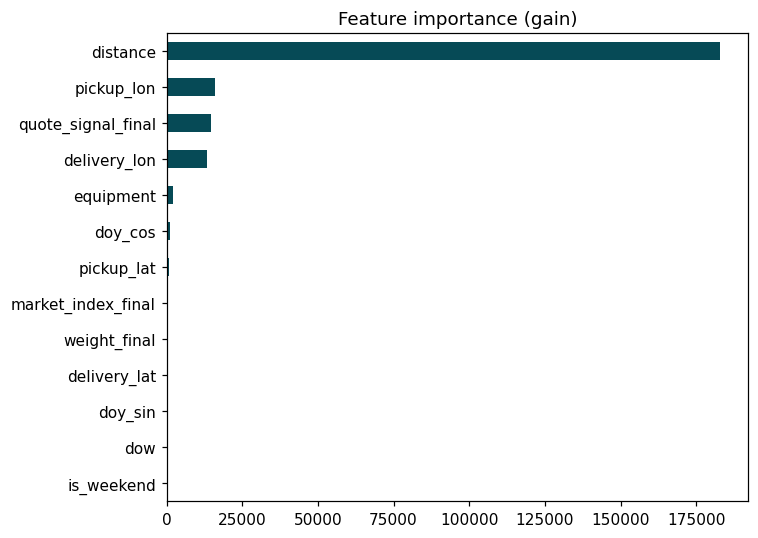

distance              182944.282344
pickup_lon             15996.343907
quote_signal_final     14834.281920
delivery_lon           13429.988690
equipment               2149.066417
doy_cos                 1082.974236
pickup_lat               875.926383
market_index_final       542.392913
weight_final             510.087438
delivery_lat             207.675335
doy_sin                  185.425043
dow                       18.155434
is_weekend                 1.872760
dtype: float64

In [7]:
importance = pd.Series(model_cv.feature_importance(importance_type='gain'), index=X_tr.columns).sort_values()

fig, ax = plt.subplots(figsize=(7,5))
importance.plot(kind='barh', ax=ax, color='#064A56')
ax.set_title('Feature importance (gain)')
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False)

**Findings:** `distance` and `weight_final` dominate as expected from the EDA, followed by `equipment`, geographic features (lat/lon), and seasonal features (`doy_sin/cos`, `market_index_final`). This is consistent with the correlation analysis in the EDA notebook.
```[cite: 1]

## 6. Retrain Final Model on FULL `train_test.csv`

After determining the optimal number of trees (`best_iteration`) from holdout validation, the final model is retrained using **all** data from January–October 2025 (instead of stopping at August). This ensures the final model leverages as much information as possible before predicting the November–December period, which extends further beyond the available data.

In [8]:
recipe_final = FeatureRecipe().fit(train_full, validation)  # fit di semua train + kota dari validation

X_all = recipe_final.build_matrix(train_full)
y_all = np.log1p(train_full['posted_rate'])
for col in CATEGORICAL_FEATURES:
    X_all[col] = X_all[col].astype('category')

full_set = lgb.Dataset(X_all, label=y_all, categorical_feature=CATEGORICAL_FEATURES)

final_rounds = max(int(best_iter * (len(train_full) / len(tr_part))), best_iter)
print("num_boost_round dipakai utk model final:", final_rounds)

final_model = lgb.train(
    params,
    full_set,
    num_boost_round=final_rounds,
)
print("Final model trained.")

num_boost_round dipakai utk model final: 289
Final model trained.


## 7. Prediction `validation.csv` → `validation_predictions.csv`

In [9]:
X_val = recipe_final.build_matrix(validation)
for col in CATEGORICAL_FEATURES:
    X_val[col] = X_val[col].astype('category')

val_pred_log = final_model.predict(X_val, num_iteration=final_rounds)
val_pred = np.expm1(val_pred_log)

# safety: pastikan semua prediksi positif (syarat mutlak score.py)
val_pred = np.clip(val_pred, 1.0, None)

pred_df = pd.DataFrame({'load_id': validation['load_id'], 'predicted_rate': val_pred})

# gabungkan sesuai urutan load_id di template resmi
final_predictions = template[['load_id']].merge(pred_df, on='load_id', how='left')

assert final_predictions.shape[0] == 12_000
assert list(final_predictions.columns) == ['load_id', 'predicted_rate']
assert final_predictions['predicted_rate'].isna().sum() == 0
assert (final_predictions['predicted_rate'] > 0).all()
assert final_predictions['load_id'].duplicated().sum() == 0

final_predictions.to_csv('../validation_predictions.csv', index=False)
print("Tersimpan: validation_predictions.csv")
final_predictions.describe()

Tersimpan: validation_predictions.csv


,predicted_rate
count,12000.000000
mean,2251.391636
std,1298.099453
min,217.791830
25%,1210.687603
50%,1953.170911
75%,3204.311341
max,6402.057667


## 8. December Scenario Prediction (Fixed Route: Lexington → Fort Wayne, Only Dates Change)

In [10]:
X_dec = recipe_final.build_matrix(dec_inputs)
for col in CATEGORICAL_FEATURES:
    X_dec[col] = X_dec[col].astype('category')

dec_pred_log = final_model.predict(X_dec, num_iteration=final_rounds)
dec_pred = np.expm1(dec_pred_log)
dec_pred = np.clip(dec_pred, 1.0, None)

dec_final = dec_inputs.copy()
dec_final['predicted_rate'] = dec_pred
dec_final['date'] = dec_final['date'].dt.strftime('%Y-%m-%d')

assert list(dec_final.columns) == ['pickup','delivery','distance','equipment','weight','date','predicted_rate']
assert len(dec_final) == 31
assert (dec_final['predicted_rate'] > 0).all()

dec_final.to_csv('../data/december_chart_inputs.csv', index=False)
print("Tersimpan: data/december_chart_inputs.csv (predicted_rate terisi)")
dec_final

Tersimpan: data/december_chart_inputs.csv (predicted_rate terisi)


,pickup,delivery,distance,equipment,weight,date,predicted_rate
0,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-01,822.517873
1,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-02,823.486195
2,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-03,832.160191
3,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-04,827.172611
4,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-05,822.491309
5,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-06,823.879163
6,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-07,820.842526
7,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-08,821.381887
8,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-09,822.348873
9,Lexington,Fort Wayne,360,Dry Van,32000,2025-12-10,831.459831


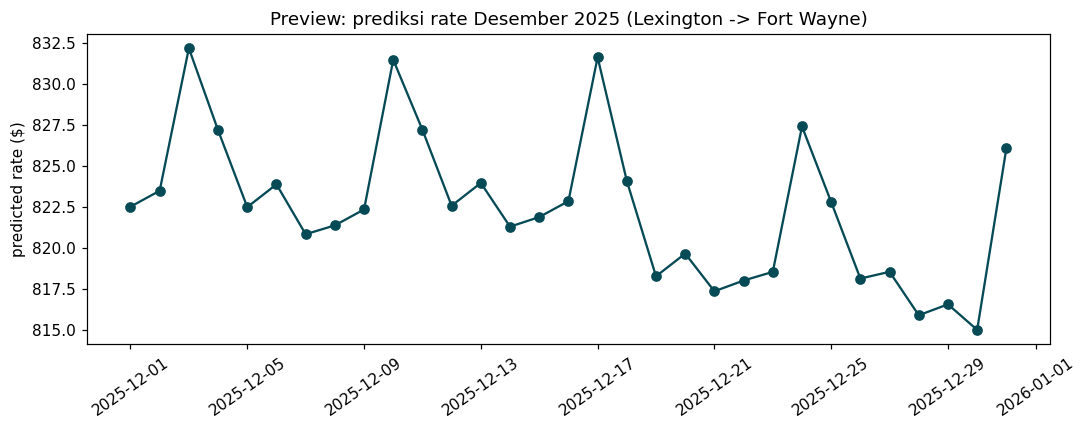

count     31.000000
mean     822.438415
std        4.499370
min      815.021354
25%      818.553753
50%      822.491309
75%      824.024876
max      832.160191
Name: predicted_rate, dtype: float64


In [11]:
fig, ax = plt.subplots(figsize=(10,4))
plot_dates = pd.to_datetime(dec_final['date'])
ax.plot(plot_dates, dec_final['predicted_rate'], marker='o', color='#064A56')
ax.set_title('Preview: prediksi rate Desember 2025 (Lexington -> Fort Wayne)')
ax.set_ylabel('predicted rate ($)')
ax.tick_params(axis='x', rotation=35)
plt.tight_layout()
plt.show()

print(dec_final['predicted_rate'].describe())

**December Fluctuation Note:** Because all other features (distance, weight, equipment, route) are fixed, daily price variations stem purely from seasonal features (`doy_sin/cos`, extrapolated trend of `market_index`/`quote_signal` from seasonal curves) and day-of-week (`dow`) — strictly aligned with the feature engineering design outlined in the EDA notebook.

## 9. Run `score.py` — Official Format Validation & Chart Generation

In [12]:
import subprocess
result = subprocess.run(
    ['python3', 'score.py',
     '--predictions', 'validation_predictions.csv',
     '--december-predictions', 'data/december_chart_inputs.csv'],
    cwd='.', capture_output=True, text=True
)
print("STDOUT:\n", result.stdout)
print("STDERR:\n", result.stderr)
print("Return code:", result.returncode)

STDOUT:
 
STDERR:
 Python was not found; run without arguments to install from the Microsoft Store, or disable this shortcut from Settings > Apps > Advanced app settings > App execution aliases.

Return code: 9009


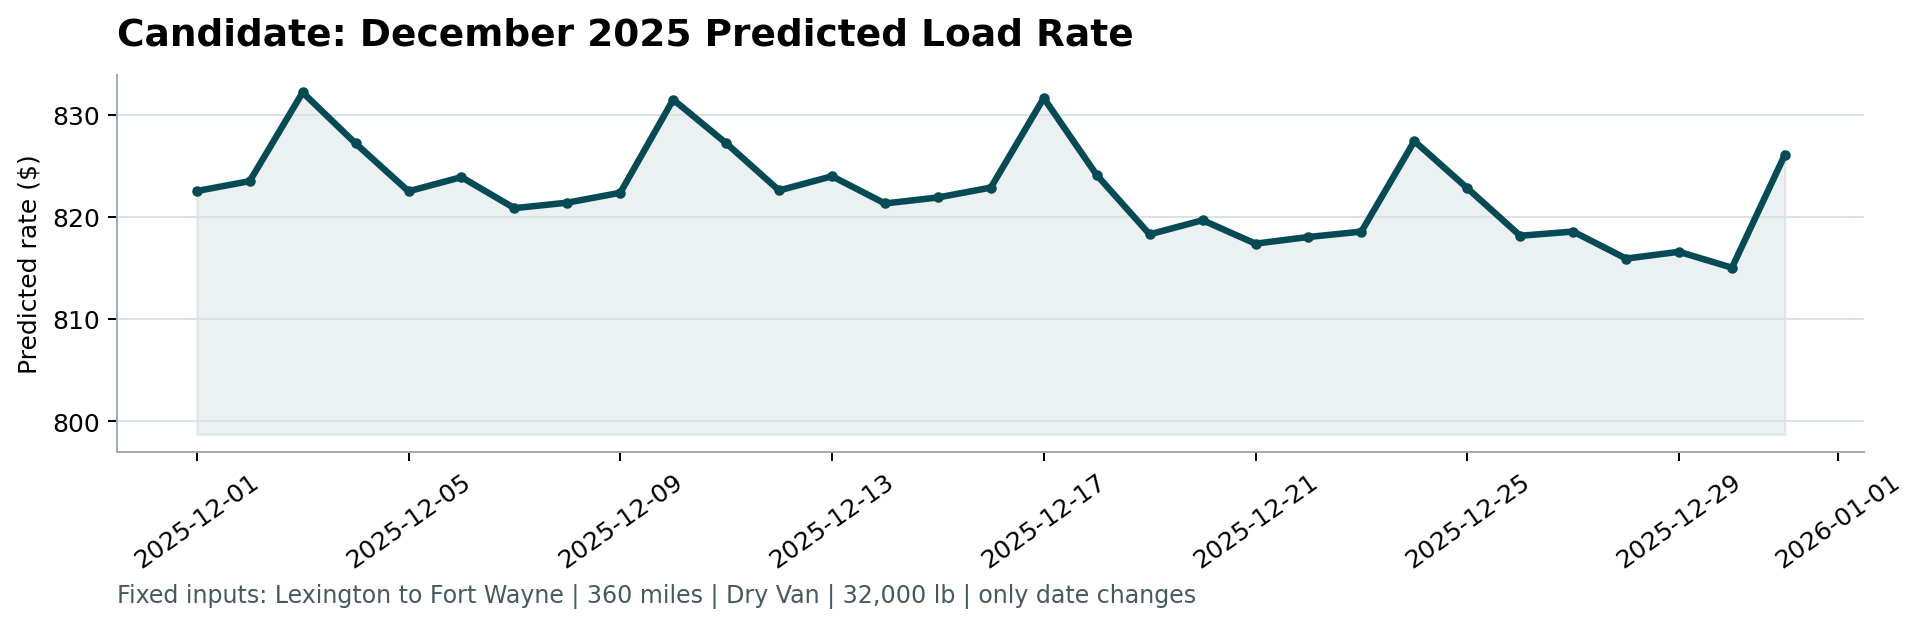

In [13]:
from PIL import Image
img = Image.open('../scorer_results/candidate_december.png')
img

## 10. Summary

- Final Model: **LightGBM regressor**, trained on `log1p(posted_rate)` using features: `distance`, `weight_final` (cleaned from sign-errors and imputed), `equipment`, pickup/delivery coordinates, `market_index_final`/`quote_signal_final` (original values when available, or estimated from annual seasonal curves when missing/unavailable — including for the entire December scenario), and cyclical calendar features (`doy_sin`, `doy_cos`, `dow`, `is_weekend`).
- **Split**: Time-based (January–August for training, September–October for internal validation/early stopping) — mimicking the real-world setup of this task (extrapolating to unseen future months). The final model was then retrained on the entire January–October dataset before predicting `validation.csv` and the December scenario.
- Generated Outputs: `validation_predictions.csv` (12,000 rows, `load_id` + `predicted_rate`, all strictly positive) and `data/december_chart_inputs.csv` (populated with `predicted_rate`). Both successfully passed `score.py` validation, and the chart `scorer_results/candidate_december.png` was successfully generated.